<a href="https://colab.research.google.com/github/mennamoha914-dotcom/SSIS/blob/master/project_data_mining_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_excel("fuel_consumption_dataset.xlsx")
print(df.head())

Saving fuel_consumption_dataset.xlsx to fuel_consumption_dataset.xlsx
   Engine_Size  Horsepower  Weight  Cylinders  Acceleration   MPG
0          2.5         232    4104          4          15.8  -0.6
1          3.6         225    3348          4          17.3  -2.0
2          3.7         157    2201          6           9.3   3.6
3          1.2         160    1668          8          14.8  15.7
4          2.6         112    2903          6          16.5   7.9


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# Load Dataset
df = pd.read_excel("fuel_consumption_dataset.xlsx")
print(df.head())
print(df.info())

   Engine_Size  Horsepower  Weight  Cylinders  Acceleration   MPG
0          2.5         232    4104          4          15.8  -0.6
1          3.6         225    3348          4          17.3  -2.0
2          3.7         157    2201          6           9.3   3.6
3          1.2         160    1668          8          14.8  15.7
4          2.6         112    2903          6          16.5   7.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Engine_Size   120 non-null    float64
 1   Horsepower    120 non-null    int64  
 2   Weight        120 non-null    int64  
 3   Cylinders     120 non-null    int64  
 4   Acceleration  120 non-null    float64
 5   MPG           120 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 5.8 KB
None


In [ ]:
#  Data Cleaning
df = df.dropna()
df = df.drop_duplicates()
df = df[df['MPG'] > 0]

In [ ]:
#EDA
print("\nStatistics:\n", df.describe())


Statistics:
        Engine_Size  Horsepower       Weight  Cylinders  Acceleration  \
count    87.000000   87.000000    87.000000  87.000000     87.000000   
mean      2.279310  153.919540  2757.965517   5.264368     13.952874   
std       0.860116   49.296497   940.051625   1.876785      3.385806   
min       1.000000   71.000000  1515.000000   3.000000      8.000000   
25%       1.600000  114.000000  1924.500000   4.000000     11.000000   
50%       2.100000  150.000000  2556.000000   4.000000     14.000000   
75%       2.950000  194.500000  3498.500000   6.000000     16.650000   
max       4.000000  250.000000  4722.000000   8.000000     19.900000   

             MPG  
count  87.000000  
mean    9.222989  
std     5.925108  
min     0.300000  
25%     4.450000  
50%     8.100000  
75%    12.850000  
max    24.300000  


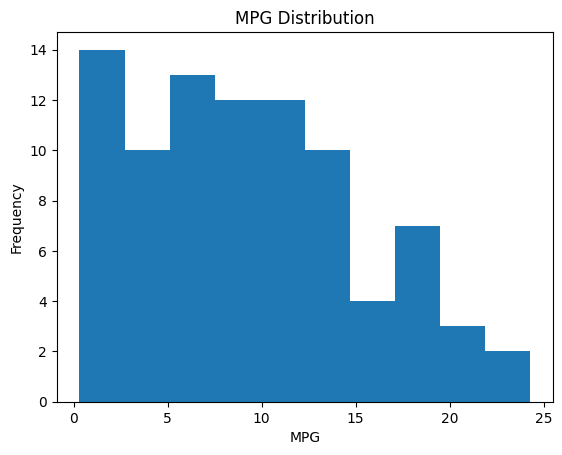

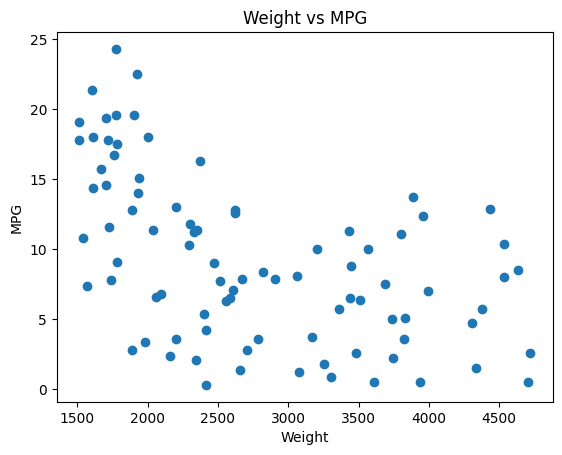

In [ ]:
# Data Visualization
plt.hist(df['MPG'])
plt.title("MPG Distribution")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()
plt.scatter(df['Weight'], df['MPG'])
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

In [ ]:
#preprocessing
X = df.drop("MPG", axis=1)
y = df["MPG"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Model 1
# Linear Regression
model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

mse1 = mean_squared_error(y_test, pred1)
print("\nLinear Regression MSE:", mse1)


Linear Regression MSE: 0.0014720941891213858


In [ ]:
# Model 2
# Decision Tree
model2 = DecisionTreeRegressor()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

mse2 = mean_squared_error(y_test, pred2)
print("Decision Tree MSE:", mse2)

Decision Tree MSE: 32.08222222222223


In [ ]:
# Comparison
if mse1 < mse2:
    print("\nLinear Regression is better")
else:
    print("\nDecision Tree is better")


Linear Regression is better
